  STEP 1: L-BFGS-B OPTIMISATION
  kappa_a       = 0.62494 hr⁻¹
  kappa_a_tilda = 0.14982 hr⁻¹
  kappa_s       = 0.01914 hr⁻¹
  gamma         = 2.01341 hr⁻¹
  log-likelihood = -123.3187
  AIC            = 254.6375
  Wall time      = 8.7 s

  95% Confidence Intervals (observed Fisher info):
  kappa_a             0.6249  [0.1705, 1.0794]
  kappa_a_tilda       0.1498  [-0.0211, 0.3208]
  kappa_s             0.0191  [-0.0170, 0.0552]
  gamma               2.0134  [0.7313, 3.2955]

  STEP 2: GRID SEARCH SANITY CHECK
  Purpose: confirm L-BFGS-B found the global maximum,
  not a local one.  Coarse 6^4 = 1296-point log-spaced grid
  centred on MLE ±4×, followed by gradient polishing of best.

  Grid ranges (log-spaced, 6 pts each):
    kappa_a             [0.1562, 2.4998]
    kappa_a_tilda       [0.0375, 0.5993]
    kappa_s             [0.0048, 0.0766]
    gamma               [0.5034, 8.0536]
  Total evaluations: 1296
  ... 300/1296  best LL = -125.6906  ETA 35s
  ... 600/1296  best LL = -123.9

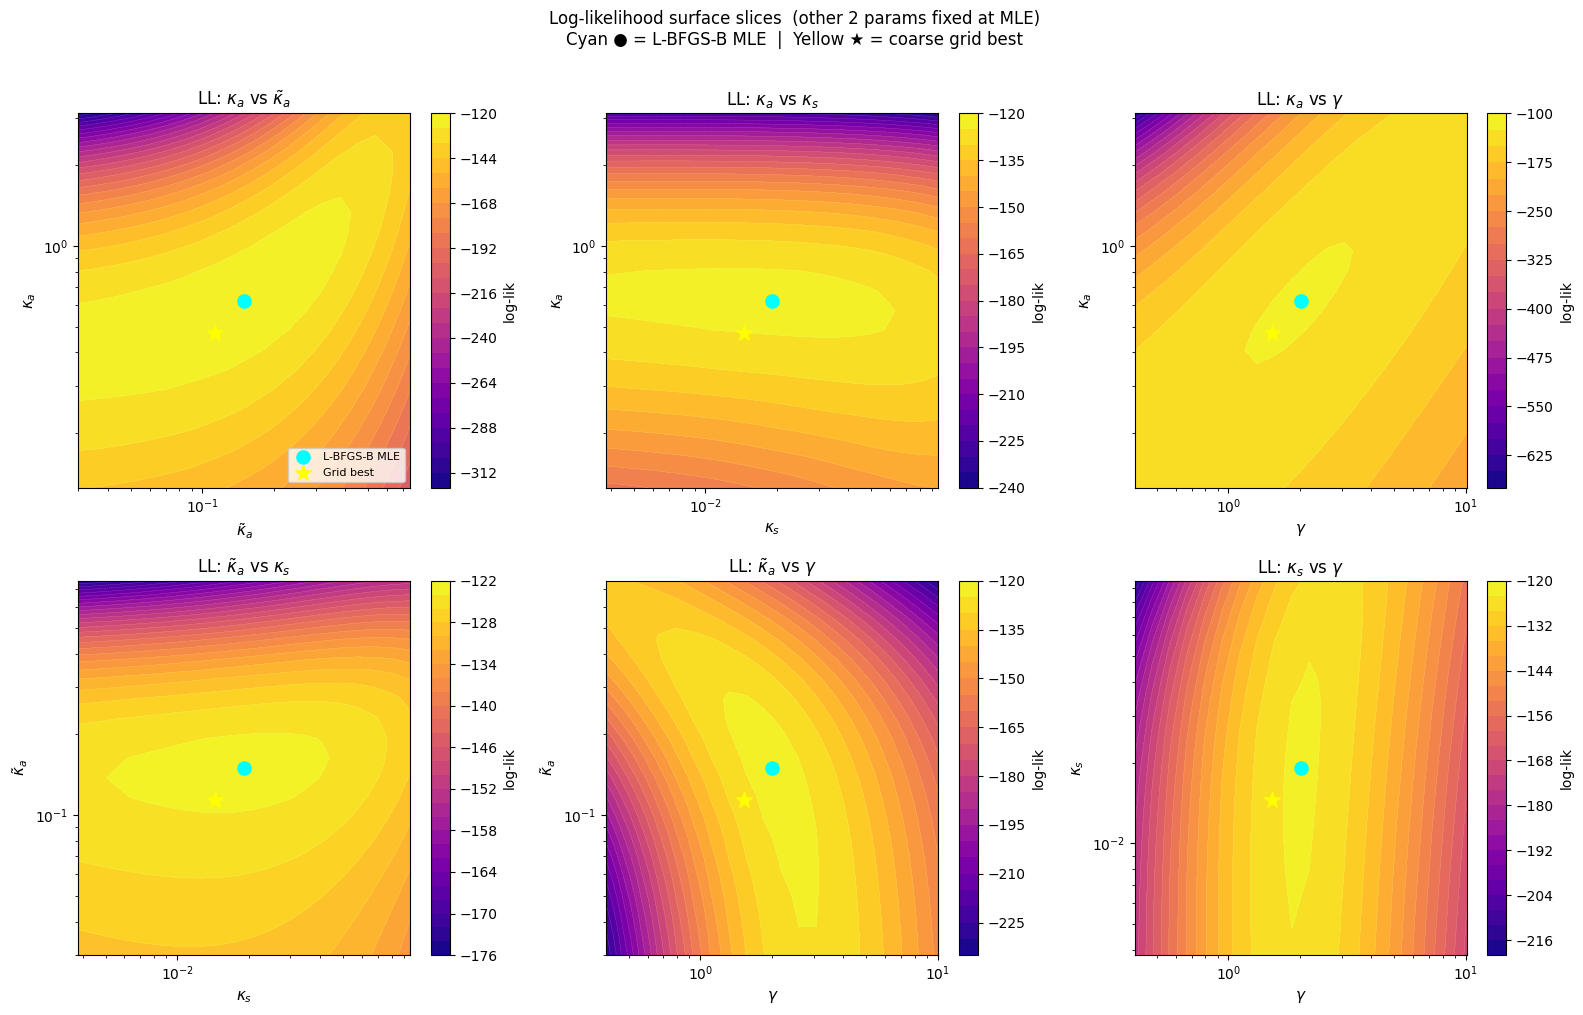

  Saved: ll_surface_slices.png


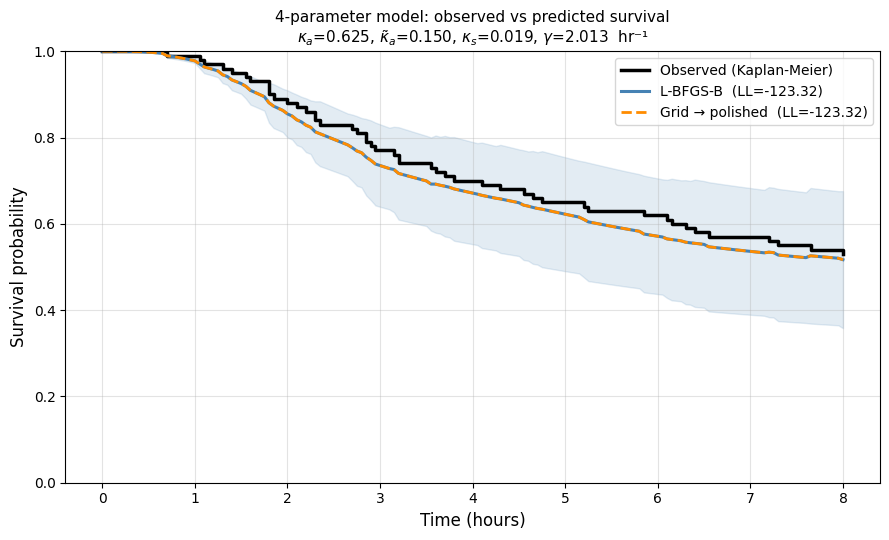

  Saved: survival_fit.png

All done.


In [1]:


import matplotlib
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from itertools import product as iproduct
from collections import Counter
import time

# ── 1. PARSE ──────────────────────────────────────────────────────────────────
DT = 0.05
CENSOR = 161

dead, alive = {}, {}
for cid, events in data.items():
    T = events[-1]
    (dead if T != CENSOR else alive)[cid] = events

def build_contact_histories(data):
    histories = {}
    zero_dur = []
    for cid, events in data.items():
        T = events[-1]
        Na = np.zeros(T, dtype=np.float64)
        Ns = np.zeros(T, dtype=np.float64)
        for ev in events[:-1]:
            s, e, typ = ev
            if s >= e:
                zero_dur.append((cid, s, e, typ))
                continue
            if typ == 1:
                Na[s-1:e] += 1
            else:
                Ns[s-1:e] += 1
        histories[cid] = {'Na': Na, 'Ns': Ns}
    if zero_dur:
        print(f"[Data check] {len(zero_dur)} zero-duration contact(s) skipped:")
        for cid, s, e, typ in zero_dur:
            print(f"  {cid}: [{s},{e}] {'adherent' if typ==1 else 'suspension'}")
    return histories

histories = build_contact_histories({**dead, **alive})

# ── 3. VECTORISED HAZARD ─────────────────────────────────────────────────────

def compute_d_and_D(Na, Ns, ka, ka_tilda, ks, g):
    """
    Returns (d_vals, D_total) where:
      d_vals : instantaneous hazard at each frame t  (length T)
      D_total: cumulative hazard ∫₀^T d dt ≈ sum(d)*DT
    """
    T = len(Na)
    tau_idx = np.arange(T)          # 0..T-1  (frame indices)
    tau_t   = tau_idx * DT          # actual times

    # Adherent kernel weight at frame tau: ka * exp(-ka_tilda * tau)
    w_a = ka * np.exp(-ka_tilda * tau_t) * Na   # shape (T,)
    # Suspension kernel weight at frame tau: ks * Ns[tau]
    w_s = ks * Ns                               # shape (T,)

    # Build lower-triangular decay matrix:
    # M[t, tau] = exp(-g*(t-tau)*DT) for tau <= t
    t_idx   = tau_idx[:, None]   # column (broadcast to T x T)
    tau_idx2 = tau_idx[None, :]  # row
    decay = np.exp(-g * np.maximum(t_idx - tau_idx2, 0) * DT)
    mask  = (tau_idx2 <= t_idx).astype(np.float64)
    M = decay * mask   # shape (T, T); M[t, tau]

    # d[t] = (M @ (w_a + w_s)) * DT
    d_vals = M @ (w_a + w_s) * DT

    D_total = d_vals.sum() * DT
    return d_vals, D_total


# ── 4. LOG-LIKELIHOOD ─────────────────────────────────────────────────────────
def log_likelihood(params, histories, dead, alive):
    ka, ka_tilda, ks, g = params
    if any(p <= 0 for p in params):
        return -np.inf
    ll = 0.0
    for cid in dead:
        h = histories[cid]
        d_vals, D = compute_d_and_D(h['Na'], h['Ns'], ka, ka_tilda, ks, g)
        d = d_vals[-1]
        if d <= 0:
            return -np.inf
        ll += np.log(d) - D
    for cid in alive:
        h = histories[cid]
        _, D = compute_d_and_D(h['Na'], h['Ns'], ka, ka_tilda, ks, g)
        ll -= D
    return ll

neg_ll = lambda p: -log_likelihood(p, histories, dead, alive)

# ── 5. L-BFGS-B MLE ──────────────────────────────────────────────────────────
print("=" * 62)
print("  STEP 1: L-BFGS-B OPTIMISATION")
print("=" * 62)
t0 = time.time()
initial = [0.9, 0.2, 0.1, 0.3]
bounds  = [(1e-10, None)] * 4

result = minimize(neg_ll, initial, method='L-BFGS-B', bounds=bounds,
                  options={'ftol': 1e-9, 'maxiter': 2000})

ka_mle, ka_tilda_mle, ks_mle, g_mle = result.x
ll_max = -result.fun
t_lbfgs = time.time() - t0

names = ['kappa_a', 'kappa_a_tilda', 'kappa_s', 'gamma']
print(f"  kappa_a       = {ka_mle:.5f} hr⁻¹")
print(f"  kappa_a_tilda = {ka_tilda_mle:.5f} hr⁻¹")
print(f"  kappa_s       = {ks_mle:.5f} hr⁻¹")
print(f"  gamma         = {g_mle:.5f} hr⁻¹")
print(f"  log-likelihood = {ll_max:.4f}")
print(f"  AIC            = {2*4 - 2*ll_max:.4f}")
print(f"  Wall time      = {t_lbfgs:.1f} s")

# ── 6. STANDARD ERRORS ────────────────────────────────────────────────────────
def hessian_fd(f, x, eps=1e-5):
    n = len(x)
    H = np.zeros((n, n))
    f0 = f(x)
    for i in range(n):
        for j in range(i, n):
            if i == j:
                xp, xm = x.copy(), x.copy()
                xp[i] += eps; xm[i] -= eps
                H[i, i] = (f(xp) - 2*f0 + f(xm)) / eps**2
            else:
                xpp, xpm, xmp, xmm = [x.copy() for _ in range(4)]
                xpp[i] += eps; xpp[j] += eps
                xpm[i] += eps; xpm[j] -= eps
                xmp[i] -= eps; xmp[j] += eps
                xmm[i] -= eps; xmm[j] -= eps
                H[i,j] = (neg_ll(xpp)-neg_ll(xpm)-neg_ll(xmp)+neg_ll(xmm))/(4*eps**2)
                H[j,i] = H[i,j]
    return H

H   = hessian_fd(neg_ll, result.x)
cov = np.linalg.inv(H)
se  = np.sqrt(np.diag(cov))
print("\n  95% Confidence Intervals (observed Fisher info):")
for nm, est, s in zip(names, result.x, se):
    lo, hi = est - 1.96*s, est + 1.96*s
    print(f"  {nm:<18}  {est:.4f}  [{lo:.4f}, {hi:.4f}]")

# ── 7. GRID SEARCH ────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("  STEP 2: GRID SEARCH SANITY CHECK")
print("=" * 62)
print("  Purpose: confirm L-BFGS-B found the global maximum,")
print("  not a local one.  Coarse 6^4 = 1296-point log-spaced grid")
print("  centred on MLE ±4×, followed by gradient polishing of best.")

def make_range(v, n=6):
    return np.logspace(np.log10(max(1e-4, v/4)), np.log10(min(20., v*4)), n)

grid = [make_range(v) for v in result.x]
n_pts = len(grid[0])
n_grid = n_pts**4

print(f"\n  Grid ranges (log-spaced, {n_pts} pts each):")
for nm, g_ in zip(names, grid):
    print(f"    {nm:<18}  [{g_.min():.4f}, {g_.max():.4f}]")
print(f"  Total evaluations: {n_grid}")

t1 = time.time()
best_ll_grid   = -np.inf
best_params_grid = None

for i, combo in enumerate(iproduct(*grid)):
    ll = log_likelihood(list(combo), histories, dead, alive)
    if ll > best_ll_grid:
        best_ll_grid = ll
        best_params_grid = combo
    if (i+1) % 300 == 0:
        elapsed = time.time() - t1
        eta = elapsed / (i+1) * (n_grid - i - 1)
        print(f"  ... {i+1}/{n_grid}  best LL = {best_ll_grid:.4f}  ETA {eta:.0f}s")

t_grid = time.time() - t1
print(f"\n  Grid search done in {t_grid:.1f} s")
print(f"  Grid best:")
for nm, v in zip(names, best_params_grid):
    print(f"    {nm:<18} = {v:.5f}")
print(f"    log-likelihood   = {best_ll_grid:.4f}")

# Polish the grid best
result_gp = minimize(neg_ll, list(best_params_grid), method='L-BFGS-B',
                     bounds=bounds, options={'ftol':1e-9,'maxiter':2000})
ll_gp = -result_gp.fun
print(f"\n  After polishing grid best:")
for nm, v in zip(names, result_gp.x):
    print(f"    {nm:<18} = {v:.5f}")
print(f"    log-likelihood   = {ll_gp:.4f}")

# ── 8. COMPARISON TABLE ───────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("  COMPARISON: L-BFGS-B  vs  Grid→Polished")
print("=" * 62)
print(f"  {'Parameter':<20}{'L-BFGS-B':>12}{'Grid (polished)':>17}{'|Δ|':>10}")
print("  " + "─" * 59)
for nm, v1, v2 in zip(names, result.x, result_gp.x):
    print(f"  {nm:<20}{v1:>12.5f}{v2:>17.5f}{abs(v1-v2):>10.2e}")
print(f"  {'log-likelihood':<20}{ll_max:>12.4f}{ll_gp:>17.4f}{abs(ll_max-ll_gp):>10.2e}")
agree = abs(ll_max - ll_gp) < 0.5
print(f"\n  Verdict: {'✓ Both agree — L-BFGS-B found the global optimum.' if agree else '⚠ LL gap > 0.5 — possible local optimum. Investigate.'}")

# ── 9. KAPLAN-MEIER ───────────────────────────────────────────────────────────
n_total      = len(data)
dead_T       = [events[-1] for events in data.values() if events[-1] != CENSOR]
death_counts = Counter(dead_T)
unique_T     = sorted(death_counts)

n_at_risk = n_total
km_surv, km_times = [1.0], [0.0]
for t in unique_T:
    k = death_counts[t]
    km_surv.append(km_surv[-1] * (1 - k / n_at_risk))
    n_at_risk -= k
    km_times.append(t * DT)

# ── 10. MODEL SURVIVAL CURVES ─────────────────────────────────────────────────
def model_survival(params, histories, n_total, CENSOR):
    surv_all = []
    for cid in histories:
        Na, Ns = histories[cid]['Na'], histories[cid]['Ns']
        d_vals, _ = compute_d_and_D(Na, Ns, *params)
        D_traj = np.cumsum(d_vals) * DT
        sv = np.exp(-D_traj)
        padded = np.full(CENSOR, np.nan)
        padded[:len(sv)] = sv
        surv_all.append(padded)
    arr = np.array(surv_all)
    valid  = np.sum(~np.isnan(arr), axis=0)
    upper  = np.nansum(arr, axis=0) / valid
    lower  = np.nansum(np.nan_to_num(arr), axis=0) / n_total
    return (upper + lower) / 2, lower, upper

mean_mle, low_mle, up_mle = model_survival(result.x,    histories, n_total, CENSOR)
mean_gp,  low_gp,  up_gp  = model_survival(result_gp.x, histories, n_total, CENSOR)

# ── 11. LL SURFACE SLICES (2-D heatmaps) ─────────────────────────────────────
print("\nComputing 2-D log-likelihood surface slices for heatmaps...")
n_heat = 20
param_labels = [r'$\kappa_a$', r'$\tilde{\kappa}_a$', r'$\kappa_s$', r'$\gamma$']
heat_grids = [np.logspace(np.log10(max(1e-4, v/5)), np.log10(v*5), n_heat)
              for v in result.x]

pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
fig_heat, axes_heat = plt.subplots(2, 3, figsize=(16, 10))
axes_heat = axes_heat.flatten()

for ax_idx, (pi, pj) in enumerate(pairs):
    Z = np.zeros((n_heat, n_heat))
    fixed = list(result.x)
    for ii, vi in enumerate(heat_grids[pi]):
        for jj, vj in enumerate(heat_grids[pj]):
            p = list(fixed)
            p[pi] = vi; p[pj] = vj
            Z[ii, jj] = log_likelihood(p, histories, dead, alive)

    ax = axes_heat[ax_idx]
    im = ax.contourf(heat_grids[pj], heat_grids[pi], Z, levels=25, cmap='plasma')
    ax.contour(heat_grids[pj], heat_grids[pi], Z, levels=25,
               colors='white', linewidths=0.25, alpha=0.35)
    plt.colorbar(im, ax=ax, label='log-lik')

    # MLE (L-BFGS-B)
    ax.scatter([result.x[pj]], [result.x[pi]], color='cyan', s=90, zorder=6,
               marker='o', label='L-BFGS-B MLE')
    # Grid best (raw, before polish)
    ax.scatter([best_params_grid[pj]], [best_params_grid[pi]], color='yellow',
               marker='*', s=140, zorder=7, label='Grid best')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(param_labels[pj], fontsize=11)
    ax.set_ylabel(param_labels[pi], fontsize=11)
    ax.set_title(f'LL: {param_labels[pi]} vs {param_labels[pj]}')
    if ax_idx == 0:
        ax.legend(fontsize=8, loc='lower right')

fig_heat.suptitle(
    'Log-likelihood surface slices  (other 2 params fixed at MLE)\n'
    'Cyan ● = L-BFGS-B MLE  |  Yellow ★ = coarse grid best',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print("  Saved: ll_surface_slices.png")

# ── 12. SURVIVAL PLOT ─────────────────────────────────────────────────────────
t_plot = np.arange(CENSOR) * DT

fig2, ax2 = plt.subplots(figsize=(9, 5.5))
ax2.step(km_times, km_surv, where='post', color='black', lw=2.5,
         label='Observed (Kaplan-Meier)')
ax2.fill_between(t_plot, low_mle, up_mle, color='steelblue', alpha=0.15)
ax2.plot(t_plot, mean_mle, color='steelblue', lw=2.2,
         label=f'L-BFGS-B  (LL={ll_max:.2f})')
ax2.plot(t_plot, mean_gp,  color='darkorange', lw=2.0, ls='--',
         label=f'Grid → polished  (LL={ll_gp:.2f})')
ax2.set_xlabel('Time (hours)', fontsize=12)
ax2.set_ylabel('Survival probability', fontsize=12)
ax2.set_title(
    '4-parameter model: observed vs predicted survival\n'
    rf'$\kappa_a$={ka_mle:.3f}, $\tilde{{\kappa}}_a$={ka_tilda_mle:.3f}, '
    rf'$\kappa_s$={ks_mle:.3f}, $\gamma$={g_mle:.3f}  hr⁻¹', fontsize=11)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()
print("  Saved: survival_fit.png")

print("\nAll done.")